<a href="https://colab.research.google.com/github/jackieuxui/tripleten-project9-featureengineering/blob/main/Project9_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Feature Engineering

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils import shuffle

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

import seaborn as sns


In [ ]:
# Load Datasets
data = pd.read_csv('/datasets/Churn.csv')

In [ ]:
# Inspect Data
print(data.head())
print(data.info())
print(data.describe())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0               1   
2     8.0  159660.80              3          1               0   
3     1.0       0.00              2          0               0   
4     2.0  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

The Churn dataset has 10,000 rows and 14 columns. The data contains mixed datatypes of int64, object, and float.

The `int64` column includes:
* `CustomerId`
* `CreditScore`
* `Age`
* `NumOfProducts`
* `HasCrCard`
* `IsActiveMember`
* `Exited`

The `object` columns include:
* `Surname`
* `Geography`
* `Gender`

The`float64` columns include:
* `Tenure`
* `Balance`
* `EstimatedSalary`

`Tenure` appears to have some missing values and may require preprocessing.

## Data Cleaning / Preprocessing

In [ ]:
#Create working copy
df_clean = data.copy()

In [ ]:
# Standardize column names
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
)

In [ ]:
#Check duplicate IDs
duplicated_ids= df_clean[df_clean['customerid'].duplicated()]

print(duplicated_ids)

Empty DataFrame
Columns: [rownumber, customerid, surname, creditscore, geography, gender, age, tenure, balance, numofproducts, hascrcard, isactivemember, estimatedsalary, exited]
Index: []


In [ ]:
# Inspect Missing Values

df_clean['tenure'].isna().sum()

909

In [ ]:
# Fill missing tenure values with median
df_clean['tenure'] = df_clean['tenure'].fillna(
    df_clean['tenure'].median()
)

In [ ]:
df_clean.describe()

,rownumber,customerid,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.99790,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.76001,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Data column names were standardized with lowercase letters. There were no duplicate customer ids, and the 909 missing values in `tenure` was replaced with the median. Choosing the median will preserve shape distribution and introduce less distortion.

## Feature Processing

Irrelevant columns will be drop such as `rownumber`,`customerid`, and `surname` as it does not indicate clients' behavior.

Categorical columns such as `geography` and `gender` will be converted to numerical using One-Hot-Encoding (OHE) for future analysis.

Feature scaling will be conducted in `crediscore`, `age`,`tenure`,`balance`, `estimatedsalary`

In [ ]:
# Dropping irrelevant columns
df_clean.columns

df_clean= df_clean.drop(['rownumber','customerid','surname'],axis=1)


In [ ]:
# Categorical columns(Geography and Gender)
unique_geo =  df_clean['geography'].unique()
print(unique_geo)

unique_gender = df_clean['gender'].unique()
print(unique_gender)

#Using OHE
geography_ohe = pd.get_dummies(df_clean['geography'], drop_first=True)
gender_ohe = pd.get_dummies(df_clean['gender'], drop_first=True)

#Replacing geography and gender columns with ohe columns
df_clean = pd.concat([df_clean, geography_ohe,gender_ohe], axis=1)


#drop geography and gender
df_clean = df_clean.drop(['geography','gender'], axis=1)

print(df_clean.columns)


['France' 'Spain' 'Germany']
['Female' 'Male']
Index(['creditscore', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'Germany', 'Spain',
       'Male'],
      dtype='object')


### Feature Scaling

In [ ]:
print(df_clean.describe())

        creditscore           age       tenure        balance  numofproducts  \
count  10000.000000  10000.000000  10000.00000   10000.000000   10000.000000   
mean     650.528800     38.921800      4.99790   76485.889288       1.530200   
std       96.653299     10.487806      2.76001   62397.405202       0.581654   
min      350.000000     18.000000      0.00000       0.000000       1.000000   
25%      584.000000     32.000000      3.00000       0.000000       1.000000   
50%      652.000000     37.000000      5.00000   97198.540000       1.000000   
75%      718.000000     44.000000      7.00000  127644.240000       2.000000   
max      850.000000     92.000000     10.00000  250898.090000       4.000000   

         hascrcard  isactivemember  estimatedsalary        exited  \
count  10000.00000    10000.000000     10000.000000  10000.000000   
mean       0.70550        0.515100    100090.239881      0.203700   
std        0.45584        0.499797     57510.492818      0.402769   
min

In [ ]:
# Two-step 60/20/20 split features and target
feature = df_clean.drop(['exited'],axis=1)
target = df_clean['exited']


X_trainval, X_test,y_trainval, y_test = train_test_split(feature, target, test_size=0.20, random_state=12345)
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=12345)


In [ ]:
# Apply StandardScaler

X_train_scale = X_train[['creditscore', 'age', 'tenure', 'balance', 'estimatedsalary']]
X_valid_scale = X_valid[['creditscore', 'age', 'tenure', 'balance', 'estimatedsalary']]


standard_scaler = StandardScaler()
standard_scaler.fit(X_train_scale)
X_train_standard = standard_scaler.transform(X_train_scale)
X_valid_standard = standard_scaler.transform(X_valid_scale)    # Apply same scaling to test data




In [ ]:
print(X_train_standard)

[[-0.13404813 -0.0780676  -0.36911345  0.07616317  0.33157073]
 [-1.01079765  0.49455539 -0.00741482  0.13639087 -0.72785805]
 [ 0.6395544   1.35348989 -1.45420934  0.35843537 -0.47700577]
 ...
 [ 0.5673515  -0.6506906   1.4393797  -1.2324417  -1.20225745]
 [-0.41254504  0.49455539 -1.09251071  0.61552424 -0.03893121]
 [ 1.05214241 -1.89137375  1.4393797  -1.2324417   1.56093208]]


In [ ]:
# Turn into dataframe
X_train_scaled = pd.DataFrame(X_train_standard, X_train_scale.index, X_train_scale.columns)
X_valid_scaled = pd.DataFrame(X_valid_standard, X_valid_scale.index, X_valid_scale.columns)

# Drop unscaled columns
X_train = X_train.drop(X_train_scale.columns,axis=1)
X_train = pd.concat([X_train,X_train_scaled], axis=1)

X_valid = X_valid.drop(X_valid_scale.columns,axis=1)
X_valid= pd.concat([X_valid,X_valid_scaled], axis=1)


# Classification metrics

From the description, the average of `exited` is around 0.2 churners, indicating a possible imbalance. The balance will then be examined and compared.


### Training model without taking into account the imbalance: Logistic Regression

In [ ]:
model = LogisticRegression(random_state=12345)
model.fit(X_train,y_train)
predictions = model.predict(X_valid)

accuracy = accuracy_score(y_valid,predictions)
precision = precision_score(y_valid,predictions)
recall = recall_score(y_valid,predictions)
f1 = f1_score(y_valid,predictions)
matrix = confusion_matrix(y_valid,predictions)

print(f'The accuracy using Logistric Regression is: {accuracy}')
print(f'The precision using Logistric Regression is: {precision}')
print(f'The recall using Logistric Regression is: {recall}')
print(f'The f1 using Logistric Regression is: {f1}')
print(f'The confusion matrix:\n {matrix}')

The accuracy using Logistric Regression is: 0.8145
The precision using Logistric Regression is: 0.5714285714285714
The recall using Logistric Regression is: 0.20460358056265984
The f1 using Logistric Regression is: 0.30131826741996237
The confusion matrix:
 [[1549   60]
 [ 311   80]]


Classification metrics from Logistic Regression revealed a 81.5% accuracy, 57.1% precision, 20.5% recall, and 30.1% F1 scores. The confusion matrix showed 1549 non-churners correctly predicted, 80 churners correctly predicted, 60 non-churners wrongly flagged as churners, and 311 actual churners missed by the model. The high accuracy is misleading because a significant number of churners are still missed. This model also fails to have at least 0.59 F1 score. The root cause could be class imbalance, with the model biased toward predicting the majority class(non-churner).

In [ ]:
### Training weight-balance model: Logistic Regression

In [ ]:
model = LogisticRegression(random_state=12345, solver='liblinear', class_weight = 'balanced')
model.fit(X_train,y_train)
predictions = model.predict(X_valid)

accuracy = accuracy_score(y_valid,predictions)
precision = precision_score(y_valid,predictions)
recall = recall_score(y_valid,predictions)
f1 = f1_score(y_valid,predictions)
matrix = confusion_matrix(y_valid,predictions)

print(f'The accuracy using Logistric Regression is: {accuracy}')
print(f'The precision using Logistric Regression is: {precision}')
print(f'The recall using Logistric Regression is: {recall}')
print(f'The f1 using Logistric Regression is: {f1}')
print(f'The confusion matrix:\n {matrix}')

The accuracy using Logistric Regression is: 0.705
The precision using Logistric Regression is: 0.36388508891928867
The recall using Logistric Regression is: 0.680306905370844
The f1 using Logistric Regression is: 0.4741532976827095
The confusion matrix:
 [[1144  465]
 [ 125  266]]


The recall and F1 sigficantly increased to 68.0% and 47.4%, respectively. However, F1 score did not meet 59% target.

In [ ]:
### Upsampling

In [ ]:
## Repeat = 4


def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    X_train, y_train, 4
)

# < write code here >
#Train
model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_valid = model.predict(X_valid)


print('F1:', f1_score(y_valid, predicted_valid))


F1: 0.4771126760563381


In [ ]:
## Repeat == 5

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    X_train, y_train, 5

)

# < write code here >
#Train
model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_valid = model.predict(X_valid)

print('F1:', f1_score(y_valid, predicted_valid))


F1: 0.47049689440993786


Upsampling resulted an increased of F1 score but still did not reach the 59% threshold.

In [ ]:
### Downsampling
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]


    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)]
        + [features_ones]
    )
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)]
        + [target_ones]
    )


    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345
    )


    return features_downsampled, target_downsampled


features_downsampled, target_downsampled = downsample(
    X_train, y_train, 0.25
)

#Train

model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_downsampled,target_downsampled)
predicted_valid = model.predict(X_valid)


print('F1:', f1_score(y_valid, predicted_valid))



F1: 0.4753521126760563


The Logistic Regression F1 scores are
* No balancing → 0.30
* class_weight='balanced' → 0.474
* Upsampling (repeat=4) → 0.470
* Downsampling (fraction=0.25) → 0.475

None reached the 59% F1 score threshold. Another model will be considered.

## Random Forest Model


In [ ]:
# Your task: Train Random Forest and get feature importance
rf_model = RandomForestClassifier(random_state=12345)
rf_model.fit(X_train,y_train)
predicted_valid = rf_model.predict(X_valid)
print('F1:', f1_score(y_valid, predicted_valid))



# Get feature importances
feature_importances = rf_model.feature_importances_


print("RANDOM FOREST FEATURE IMPORTANCE:")
print("=" * 40)


# Create importance DataFrame for easy sorting
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)


# Display results
for i in range(len(importance_df)):
    feature = importance_df.iloc[i]['feature']
    importance = importance_df.iloc[i]['importance']
    print("{}: {:<20} Importance: {:.4f}".format(i+1, feature, importance))


# Select top 3 features
top_features_3 = importance_df.head(3)['feature'].tolist()
print("\nTOP 3 MOST IMPORTANT FEATURES:")
for feature in top_features_3:
    print("- " + feature)


# Select top 6 features
top_features_6 = importance_df.head(6)['feature'].tolist()
print("\nTOP 6 MOST IMPORTANT FEATURES:")
for feature in top_features_6:
    print("- " + feature)



F1: 0.5454545454545454
RANDOM FOREST FEATURE IMPORTANCE:
1: age                  Importance: 0.2376
2: creditscore          Importance: 0.1433
3: estimatedsalary      Importance: 0.1431
4: balance              Importance: 0.1431
5: numofproducts        Importance: 0.1248
6: tenure               Importance: 0.0794
7: isactivemember       Importance: 0.0425
8: Germany              Importance: 0.0325
9: Male                 Importance: 0.0199
10: hascrcard            Importance: 0.0193
11: Spain                Importance: 0.0144

TOP 3 MOST IMPORTANT FEATURES:
- age
- creditscore
- estimatedsalary

TOP 6 MOST IMPORTANT FEATURES:
- age
- creditscore
- estimatedsalary
- balance
- numofproducts
- tenure


In [ ]:
## Using top three features

X_train_top_3 = X_train[top_features_3]
X_valid_top_3 = X_valid[top_features_3]

rf_model = RandomForestClassifier(random_state=12345)
rf_model.fit(X_train_top_3,y_train)
predicted_valid = rf_model.predict(X_valid_top_3)
print('F1:', f1_score(y_valid, predicted_valid))

X_train_top_6 = X_train[top_features_6]
X_valid_top_6 = X_valid[top_features_6]

rf_model = RandomForestClassifier(random_state=12345)
rf_model.fit(X_train_top_6,y_train)
predicted_valid = rf_model.predict(X_valid_top_6)
print('F1:', f1_score(y_valid, predicted_valid))

F1: 0.3084415584415584
F1: 0.44264943457189015


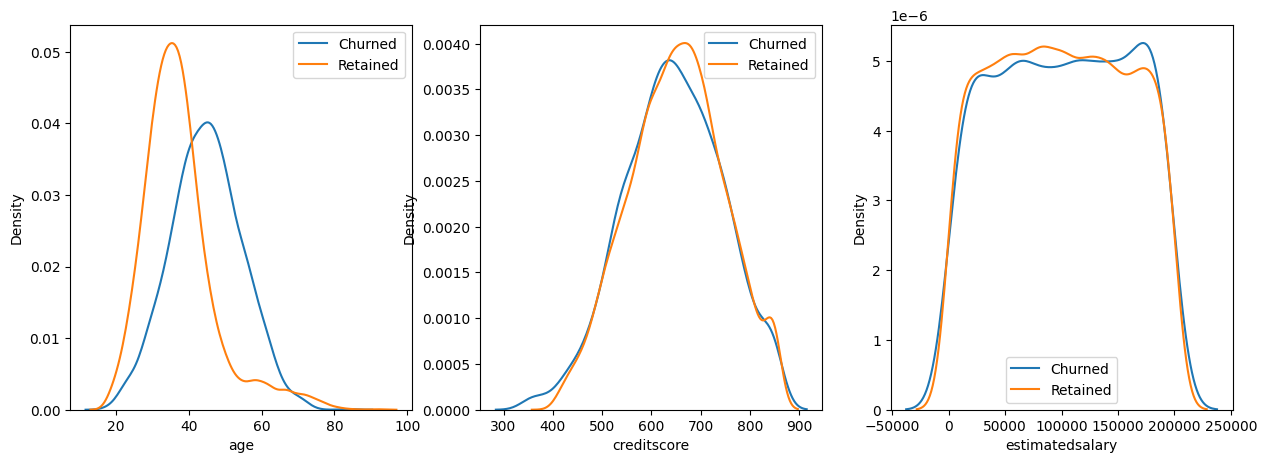

In [ ]:
# Distribution Plots of top features for churners vs retained customers
churned = df_clean[df_clean['exited'] == 1]
retained = df_clean[df_clean['exited'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# Plot 1: age
sns.kdeplot(churned['age'], ax=axes[0],label='Churned')
sns.kdeplot(retained['age'], ax=axes[0], label='Retained')
axes[0].legend()

# Plot 2: creditscore — and this one?
sns.kdeplot(churned['creditscore'], ax=axes[1],label='Churned')
sns.kdeplot(retained['creditscore'], ax=axes[1], label='Retained')
axes[1].legend()

# Plot 3: estimatedsalary — can you fill this in?
sns.kdeplot(churned['estimatedsalary'], ax=axes[2],label='Churned')
sns.kdeplot(retained['estimatedsalary'], ax=axes[2], label='Retained')
axes[2].legend()

The Top 3 most important features are:
* `age`
* `creditscore`
* `estimatedsalary`

Inspecting important features reveals a decrease in F1 score as more features are removed from 54.5% all-included, 44.2% top six features, to 30.8% top three features. This suggests that features that were removed must have been carrying useful predictive information.

In the distribution plots, the retention age peaks around 35-40, while customer churn peaks around 45-50. This means that older customers are more likely to churn than younger customers. On the other hand, the estimated salary distribution is too similar to draw a certain conclusion. The credit score also shows a subtle difference, with a slightly lower peak credit score around 600 for those who churned compared to those who were retained, with a peak around 650.

In [ ]:
## Upsampling with Random Forest

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    X_train, y_train, 1
)

# < write code here >
#Train
model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_valid = model.predict(X_valid)
print('F1 validation for repeat 9:', f1_score(y_valid, predicted_valid))

# Check for overfitting
predicted_valid = model.predict(features_upsampled)
print('F1 training for repeat 9:', f1_score(target_upsampled, predicted_valid))

F1 validation for repeat 9: 0.5568000000000001
F1 training for repeat 9: 1.0


In [ ]:
## Upsampling with Random Forest

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    X_train, y_train, 9
)

#Train
model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_valid = model.predict(X_valid)
print('F1 validation for repeat 1:', f1_score(y_valid, predicted_valid))

# Check for overfitting
predicted_valid = model.predict(features_upsampled)
print('F1 training for repeat 1:', f1_score(target_upsampled, predicted_valid))

F1 validation for repeat 1: 0.5974754558204769
F1 training for repeat 1: 1.0


A repeat of 9 has a 59.7 F1 score and meets the 59.0 threshold. Both repeat=9 and repeat=1 show overfitting, but the key difference is the F1 score meeting the threshold for repeat=9.

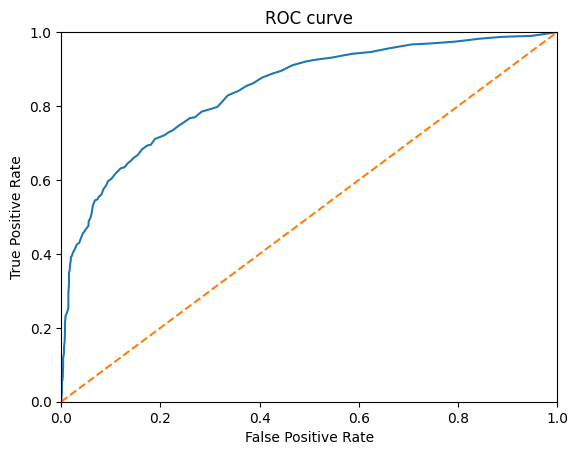

The Area under curve (AUC_ROC) is: 0.8431385795056262


In [ ]:
# ROC

model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled,target_upsampled)


probabilities_valid = model.predict_proba(X_valid)
probabilities_one_valid = probabilities_valid[:, 1]


fpr, tpr, thresholds = roc_curve(y_valid, probabilities_one_valid)# < write code here >


plt.figure()


# < plot the graph >
plt.plot(fpr,tpr)
# ROC curve for random model (looks like a straight line)
plt.plot([0, 1], [0, 1], linestyle='--')


# < use the functions plt.xlim() and plt.ylim() to
#   set the boundary for the axes from 0 to 1 >
plt.xlim([0,1])
plt.ylim([0,1])
# < use the functions plt.xlabel() and plt.ylabel() to
#   name the axes "False Positive Rate" and "True Positive Rate" >
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# < add the heading "ROC curve" with the function plt.title() >
plt.title('ROC curve')
plt.show()

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_valid,probabilities_one_valid)# < write code here >

print(f'The Area under curve (AUC_ROC) is: {auc_roc}')


The upsampled Regression Classifier increased the F1 score to 59.7%, and with an Auc_roc value of 0.843, this indicates a great model in predicting whether a customer will leave the bank soon.

# Final Testing

In [ ]:
# Apply Scaler on X_test
#X_trainval, X_test,y_trainval, y_test = train_test_split(feature, target, test_size=0.20, random_state=12345)

# Apply StandardScaler

X_trainval_scale = X_trainval[['creditscore', 'age', 'tenure', 'balance', 'estimatedsalary']]
X_test_scale = X_test[['creditscore', 'age', 'tenure', 'balance', 'estimatedsalary']]


standard_scaler = StandardScaler()
standard_scaler.fit(X_trainval_scale)
X_trainval_standard = standard_scaler.transform(X_trainval_scale)
X_test_standard = standard_scaler.transform(X_test_scale)    # Apply same scaling to test data

# Turn into dataframe
X_trainval_scaled = pd.DataFrame(X_trainval_standard, X_trainval_scale.index, X_trainval_scale.columns)
X_test_scaled = pd.DataFrame(X_test_standard, X_test_scale.index, X_test_scale.columns)

# Drop unscaled columns
X_trainval = X_trainval.drop(X_trainval_scale.columns,axis=1)
X_trainval = pd.concat([X_trainval,X_trainval_scaled], axis=1)

X_test = X_test.drop(X_test_scale.columns,axis=1)
X_test= pd.concat([X_test,X_test_scaled], axis=1)


In [ ]:
# Training and upsampling

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    X_trainval, y_trainval, 9
)

#Train
model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled,target_upsampled)
predicted_test = model.predict(X_test)
print('F1 test:', f1_score(y_test, predicted_test))

F1 test: 0.5965834428383706


# Conclusion
The goal of this project was to predict customer churn using machine learning and to identify factors most associated with customer retention. The analysis revealed that a Logistic Regression model that did not account for the class imbalance performed poorly with an F1 score of 30.0%. Utilizing a weighted class, the score increased to 47.4%, which is still below the 59% F1 score threshold. When the data was split and upsampled, the F1 score was 47.7%, and downsampled with 47.5%. These scores revealed that the Logistic Regression is a poor model for predicting churn performance and did not meet the 59% F1 threshold.

The Random Forest, on the other hand, provided a better score with 54.5%. Feature importance was derived, with `age`,`creditscore`, and `estimatedsalary` being the top features. However, it was determined that the decreasing feature sets also lowered the F1 score from 44.2% to 30.8% for the top 6 to top 3 features, respectively. Thus, upsampling was applied to all features, resulting in a 59.7% F1 score meeting the threshold. This was further validated by the AUC_ROC score of 84.3%, indicating a great model. The upsampling, however, reveals signs of overfitting.

During the final testing, the result showed an F1 score of 59.65%, similar to the validation test (59.7%), which indicated that the model generalizes well and meets the threshold.

## Business Insight:
The Random Forest model identified age, credit score, and estimated salary as the most influential features in predicting customer churn. Distribution analysis showed that customers between approximately 45 and 50 years old exhibited a higher likelihood of churning compared to younger customers. Customers with slightly lower credit scores, particularly around the 600 range, also showed an increased tendency to churn. In contrast, the estimated salary displayed substantial overlap between retained and churned customers, suggesting weaker direct separation despite its measured model importance.

The upsampled Random Forest model achieved an AUC-ROC score of 84.3%, indicating a strong ability to distinguish between customers likely to churn and those likely to remain. The bank could use this model as an early warning system to identify high-risk customers and proactively apply retention strategies.

For example, customers flagged as high churn risk could receive personalized support, loyalty incentives, retirement planning services, loan consultations, or customized savings products. Customers with lower credit scores may also benefit from financial literacy programs or one-on-one financial consultations designed to improve engagement and long-term retention.

Overall, the model enables the bank to move from reactive customer retention toward a more proactive and targeted retention strategy.

